# Risk-informed sensor network design for Texas-Gulf (HUC2: 12)

Requires:
- Outputs of `design_texas_gulf_baseline.ipynb` (streamflow, flowlines, USGS gauges)
- FEMA NRI Census-Tracts GDB — download manually from <https://www.fema.gov/about/openfema/data-sets/national-risk-index-data> and unzip to `./data/NRI_GDB_CensusTracts/`
- HUC-02 region 12 boundary shapefile, e.g. `./data/huc2_12_boundary/HU02_12.shp`

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hydrosensenet import (
    calculate_spatial_weights,
    load_nri,
    reconstruction_evaluation,
    sensor_placement_qr,
)
from hydrosensenet.data import load_usgs_gauges, match_usgs_to_nwm

## Paths

In [2]:
DATA_DIR = Path("./data/texas_gulf")
NRI_GDB = Path("./data/NRI_GDB_CensusTracts/NRI_GDB_CensusTracts.gdb")  # FEMA download
HUC2_SHP = Path("./data/huc2_12_boundary/HU02_12.shp")  # WBD HUC-02

for p in [DATA_DIR, NRI_GDB, HUC2_SHP]:
    if not p.exists():
        raise FileNotFoundError(f"Required input missing: {p}")

## Streamflow, flowlines, USGS baseline

In [3]:
import glob

streamflow_files = sorted(glob.glob(str(DATA_DIR / "streamflow_*.parquet")))
streamflow_files = [f for f in streamflow_files if "_clean" not in f]
df = (
    pd.concat([pd.read_parquet(f) for f in streamflow_files], axis=0)
    .sort_index()
)
df.columns = df.columns.astype(str)
print(f"Streamflow matrix: {df.shape[0]:,} timesteps x {df.shape[1]:,} COMIDs")

flowlines = gpd.read_file(DATA_DIR / "texas_gulf_flowlines_full.geojson")
flowlines = flowlines.rename(columns={c: "COMID" for c in flowlines.columns if c.lower() == "comid"})
flowlines["COMID"] = flowlines["COMID"].astype(str)
print(f"Flowlines:         {len(flowlines):,} segments")

usgs_gauges, comid_linkage = load_usgs_gauges(
    shapefile_path=DATA_DIR / "usgs_gauges_all.geojson",
    comid_linkage_path=DATA_DIR / "usgs_comid_linkage_all.csv",
)
usgs_comids, _ = match_usgs_to_nwm(
    usgs_gdf=usgs_gauges,
    comid_linkage=comid_linkage,
    available_comids=df.columns.astype(int).tolist(),
)
usgs_comids = [str(c) for c in usgs_comids]
usgs_location = np.array(
    [df.columns.get_loc(c) for c in usgs_comids if c in df.columns]
)
print(f"USGS baseline:     {len(usgs_location)} gauges matched")

Streamflow matrix: 16,040 timesteps x 64,954 COMIDs
Flowlines:         68,892 segments
✓ Matched 455 USGS gauges to NWM COMIDs
  Example COMIDs: [3585554, 1438379, 3168874, 1440525, 1520249]...
USGS baseline:     455 gauges matched


## FEMA NRI (clipped to HUC-02)

In [4]:
huc2 = gpd.read_file(HUC2_SHP)
risk = load_nri(NRI_GDB, scale="tract", columns=("RFLD_RISKS",), mask=huc2)
print(f"NRI tracts in Texas-Gulf: {len(risk):,}")
risk.head()

NRI tracts in Texas-Gulf: 6,336


,RFLD_RISKS,geometry
71020,61.071208,"POLYGON ((-10847076.466 2983821.253, -10847100..."
71018,64.475812,"MULTIPOLYGON (((-10848888.303 2986378.744, -10..."
71019,54.210864,"POLYGON ((-10846856.164 2985462.678, -10846936..."
71035,90.102507,"MULTIPOLYGON (((-10847758.743 2983930.997, -10..."
71033,89.205870,"POLYGON ((-10843343.921 2988462.536, -10843345..."


## Risk weights per COMID

`fill_value=1e-10` keeps uncovered COMIDs selectable by QR; `0.0` would make them unselectable.

In [5]:
flood_risk = calculate_spatial_weights(
    locations_gdf=flowlines,
    weight_source=risk,
    weight_column="RFLD_RISKS",
    id_column="COMID",
    align_to=df.columns,
    fill_value=1e-10,
)
print(f"flood_risk vector: shape={flood_risk.shape}, "
      f"min={flood_risk.min():.2e}, max={flood_risk.max():.2f}")

flood_risk vector: shape=(64954,), min=0.00e+00, max=100.00


## Sensor placement: QR vs risk-weighted QR

In [6]:
n_sensors = len(usgs_location) * 2
split = int(0.7 * len(df))
X_train = df.values[:split]
X_test = df.values[split:]

sensors_qr = sensor_placement_qr(
    X_train, n_sensors, fixed_indices=list(usgs_location)
)
sensors_risk = sensor_placement_qr(
    X_train, n_sensors,
    fixed_indices=list(usgs_location),
    weights=flood_risk,
)
print(f"QR sensors:        {len(sensors_qr)}")
print(f"Risk QR sensors:   {len(sensors_risk)}")
print(f"Overlap with USGS: {len(set(sensors_risk) & set(usgs_location))}")

QR sensors:        910
Risk QR sensors:   910
Overlap with USGS: 447


## ΔNNSE (QR − risk-QR)

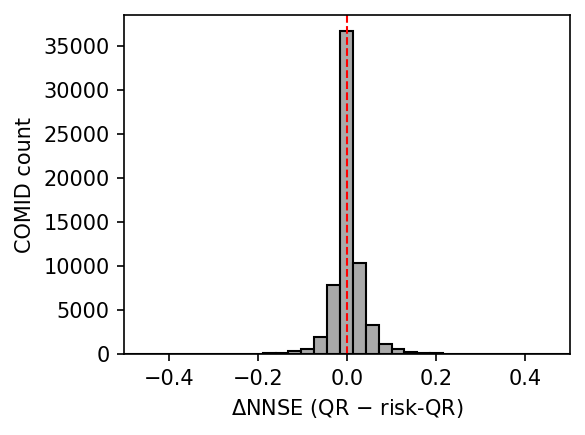

In [7]:
res_qr = reconstruction_evaluation(X_train, X_test, sensors_qr, n_sensors)
res_risk = reconstruction_evaluation(X_train, X_test, sensors_risk, n_sensors)
delta = res_qr["nnse"] - res_risk["nnse"]

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
ax.hist(delta[~np.isnan(delta)], bins=50, color="darkgrey", edgecolor="k")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel(r"$\Delta\mathrm{NNSE}$ (QR $-$ risk-QR)")
ax.set_ylabel("COMID count")
ax.set_xlim(-0.5, 0.5)
plt.tight_layout()
plt.show()

## Flood-risk CDF over selected sensors

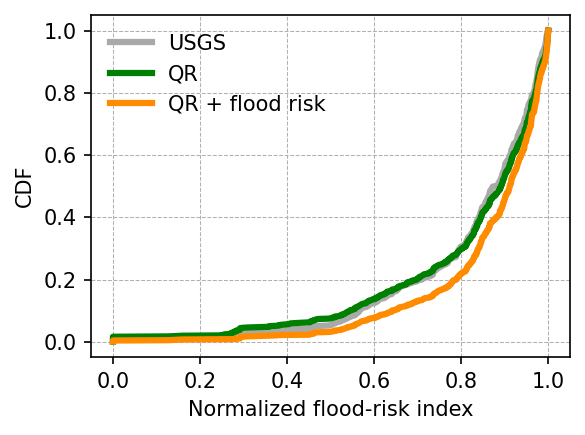

In [8]:
rng = flood_risk.max() - flood_risk.min()
normed = (flood_risk - flood_risk.min()) / rng if rng > 0 else flood_risk

def _cdf(values):
    s = np.sort(values)
    return s, np.arange(1, len(s) + 1) / len(s)

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
for label, idx, color in [
    ("USGS", usgs_location, "darkgrey"),
    ("QR", sensors_qr, "green"),
    ("QR + flood risk", sensors_risk, "darkorange"),
]:
    x, y = _cdf(normed[idx])
    ax.plot(x, y, lw=3, label=label, color=color)
ax.set_xlabel("Normalized flood-risk index")
ax.set_ylabel("CDF")
ax.grid(ls="--", lw=0.5)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()